## Measured current front speed vs the speed expected from scaling for different mixing regimes

In [5]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress
import matplotlib.patches as patches
from matplotlib.lines import Line2D

# Use given style and color maps
from colors import (
    mixing_c_map,
    type_marker_map,
    author_color,
    marker_style,
    label_map,
)

plt.style.use("james2026lock.mplstyle")

# constants
rho_water = 998.2  # Freshwater density [kg/m³]
rho_bent = 2277  # Wetted bentonite density [kg/m³]
h0 = 0.25  # initial water height [m]
l0 = 0.27  # mixing chamber length [m]
v0 = h0 * l0
a_thresh = 0.06  # m/s² for example (below this velocity taken as roughly constant)

# load experiment table
metadata = pd.read_csv("../../data/metadata/metadata.csv")
compare_data = pd.read_csv("../../data/metadata/literature_comparison.csv")
folder = "../../data/datafiles"

## New version with zoom and seperate Ri plot

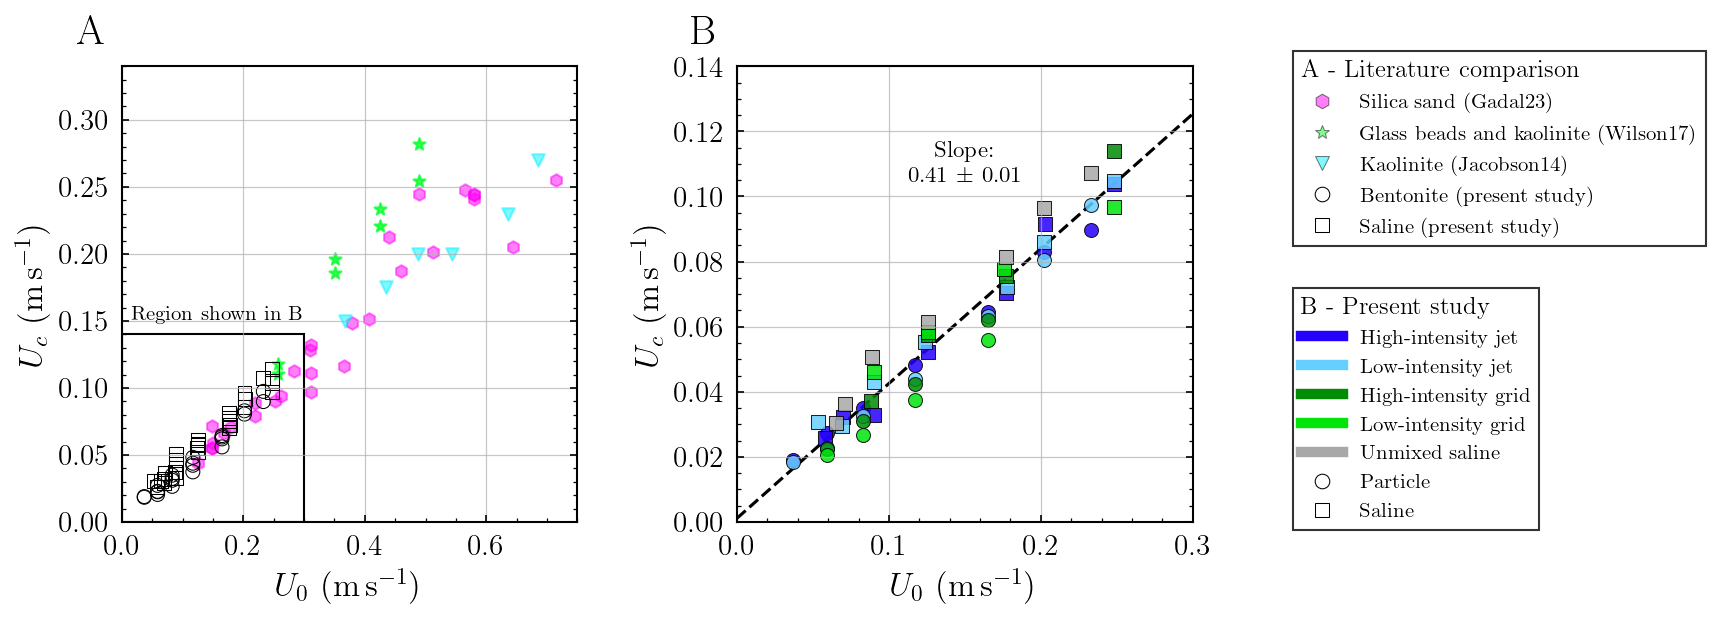

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

scatter_kw = dict(edgecolor="k", linewidth=0.5, s=45, alpha=0.85)

inset_lims = dict(xlim=[0, 0.3], ylim=[0, 0.14])

# ============= Panel A ==============
# plot all my data colored by mixing type and marker by saline/part
for mixing_type, color in mixing_c_map.items():
    for t, marker in type_marker_map.items():
        df_sub = metadata[(metadata["mixing"] == mixing_type) & (metadata["type"] == t)]
        if df_sub.empty:  # or t == "saline":
            continue
        ax[0].scatter(
            # df_sub["u_0"], df_sub["u_c"], color=color, marker=marker, **scatter_kw
            df_sub["u_0"],
            df_sub["u_c"],
            edgecolor="k",
            facecolor="none",
            marker=marker,
            linewidths=0.5,
            s=45,
        )

# axis limits and labels
ax[0].set(
    xlim=[0, 0.75],
    ylim=[0, 0.34],
    xlabel="$U_0$ (m\\,s$^{-1}$)",
    ylabel="$U_c$ (m\\,s$^{-1}$)",
)

my_legend_elements = [
    *[
        Line2D(
            [0],
            [0],
            color=color,
            linewidth=5,
            label=label_map.get(mixing_type, mixing_type),
        )
        for mixing_type, color in mixing_c_map.items()
    ],
    # Line2D([0], [0], color="k", linestyle="--", linewidth=1.5, label="Best fit (all)"),
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        label="Particle",
        markerfacecolor="white",
        markeredgecolor="k",
        markeredgewidth=0.5,
        markersize=7,
    ),
    Line2D(
        [0],
        [0],
        marker="s",
        color="w",
        label="Saline",
        markerfacecolor="white",
        markeredgecolor="k",
        markeredgewidth=0.5,
        markersize=7,
    ),
]

# add comparison experiments and legend entries
seen = set()
comp_legend_elements = []
for row in compare_data.itertuples():
    if row.particle_type == "Saline":
        continue
    author = row.author
    color = author_color[author]
    ptype = row.particle_type
    marker = marker_style[ptype]

    key = (author, ptype)

    ax[0].scatter(
        row.u_0,
        row.Fr * row.u_0,
        color=color,
        marker=marker,
        alpha=0.5,
        zorder=0,
    )
    if key not in seen:
        comp_legend_elements.append(
            Line2D(
                [0],
                [0],
                marker=marker,
                color="w",
                label=f"{ptype} ({row.short_name})",
                markerfacecolor=color,
                markeredgecolor="k",
                markeredgewidth=0.5,
                markersize=7,
                alpha=0.5,
            )
        )
        seen.add(key)
comp_legend_elements.extend(
    [
        Line2D(
            [0],
            [0],
            marker="o",
            label="Bentonite (present study)",
            markerfacecolor="none",
            markeredgecolor="k",
            markeredgewidth=0.5,
            markersize=7,
            color="w",
            linestyle="",
        ),
        Line2D(
            [0],
            [0],
            marker="s",
            label="Saline (present study)",
            markerfacecolor="none",
            markeredgecolor="k",
            markeredgewidth=0.5,
            markersize=7,
            color="w",
            linestyle="",
        ),
    ]
)

# draw inset boundaries
rect = patches.Rectangle(
    (inset_lims["xlim"][0], inset_lims["ylim"][0]),
    inset_lims["xlim"][1] - inset_lims["xlim"][0],
    inset_lims["ylim"][1] - inset_lims["ylim"][0],
    edgecolor="k",
    linestyle="-",
    linewidth=1,
    facecolor="none",
)
ax[0].add_patch(rect)

# ============== Panel B ==============

# plot all my data colored by mixing type and marker by saline/part
for mixing_type, color in mixing_c_map.items():
    for t, marker in type_marker_map.items():
        df_sub = metadata[(metadata["mixing"] == mixing_type) & (metadata["type"] == t)]
        if df_sub.empty:
            continue
        ax[1].scatter(
            df_sub["u_0"], df_sub["u_c"], color=color, marker=marker, **scatter_kw
        )

        # # best fit line for the grid low A particle data
        # if mixing_type == "grid low A" and t == "part":
        #     m, b = np.polyfit(df_sub["u_0"], df_sub["u_c"], 1)
        #     x_fit = np.linspace(0, 1, 200)
        #     ax[1].plot(x_fit, m * x_fit + b, "-", color=color, linewidth=1.5, zorder=0)


for row in compare_data.itertuples():
    author = row.author
    color = author_color[author]
    ptype = row.particle_type
    marker = marker_style[ptype]

    key = (author, ptype)

    # ax[1].scatter(
    #     row.u_0,
    #     row.Fr * row.u_0,
    #     color=color,
    #     marker=marker,
    #     alpha=0.5,
    #     zorder=0,
    # )

# now add best fit line for all data
x_fit = np.linspace(0, 1, 200)
res = linregress(metadata["u_0"], metadata["u_c"])
ax[1].plot(x_fit, res.slope * x_fit + res.intercept, "k--", linewidth=1.5, zorder=0)
ax[1].set(
    xlim=inset_lims["xlim"],
    ylim=inset_lims["ylim"],
    xlabel="$U_0$ (m\\,s$^{-1}$)",
    ylabel="$U_c$ (m\\,s$^{-1}$)",
)

# Annotate best fit lines
ax[1].text(
    0.15,
    0.105,
    "Slope:\n 0.41 $\\pm$ 0.01",
    color="k",
    fontsize=11,
    ha="center",
)

# ax[1].text(
#     0.21,
#     0.022,
#     "Slope (grid low A): \n 0.33 $\\pm$ 0.02",
#     color="g",
#     fontsize=11,
#     ha="center",
# )

# ============== Labels ==============
for axis, label in zip(ax, ["A", "B"]):
    axis.set_box_aspect(1)
    axis.annotate(
        label,
        xy=(-0.1, 1.05),
        xycoords="axes fraction",
        fontsize=20,
        fontweight="bold",
    )

ax[0].annotate("Region shown in B", xy=(0.015, 0.151), fontsize=10)
# ====== Legends ====

# Leave space on RHS for legends
fig.subplots_adjust(wspace=0.35, right=0.72)

# --- Legend 1: Literature comparison ---
leg1 = fig.legend(
    handles=comp_legend_elements,
    loc="upper left",
    bbox_to_anchor=(0.77, 0.87),
    fontsize=10,
    title="A - Literature comparison",
    frameon=True,
)

# --- Legend 2: Present study ---
leg2 = fig.legend(
    handles=my_legend_elements,
    loc="upper left",
    bbox_to_anchor=(0.77, 0.52),
    fontsize=10,
    title="B - Present study",
    frameon=True,
    ncols=1,
)

leg1._legend_box.align = "left"
leg2._legend_box.align = "left"

plt.savefig("../figures/figure_10.png", bbox_inches="tight", dpi=300)
plt.show()

### Uc/U0 With comparison to $\Delta \rho$ and Ri$_0$

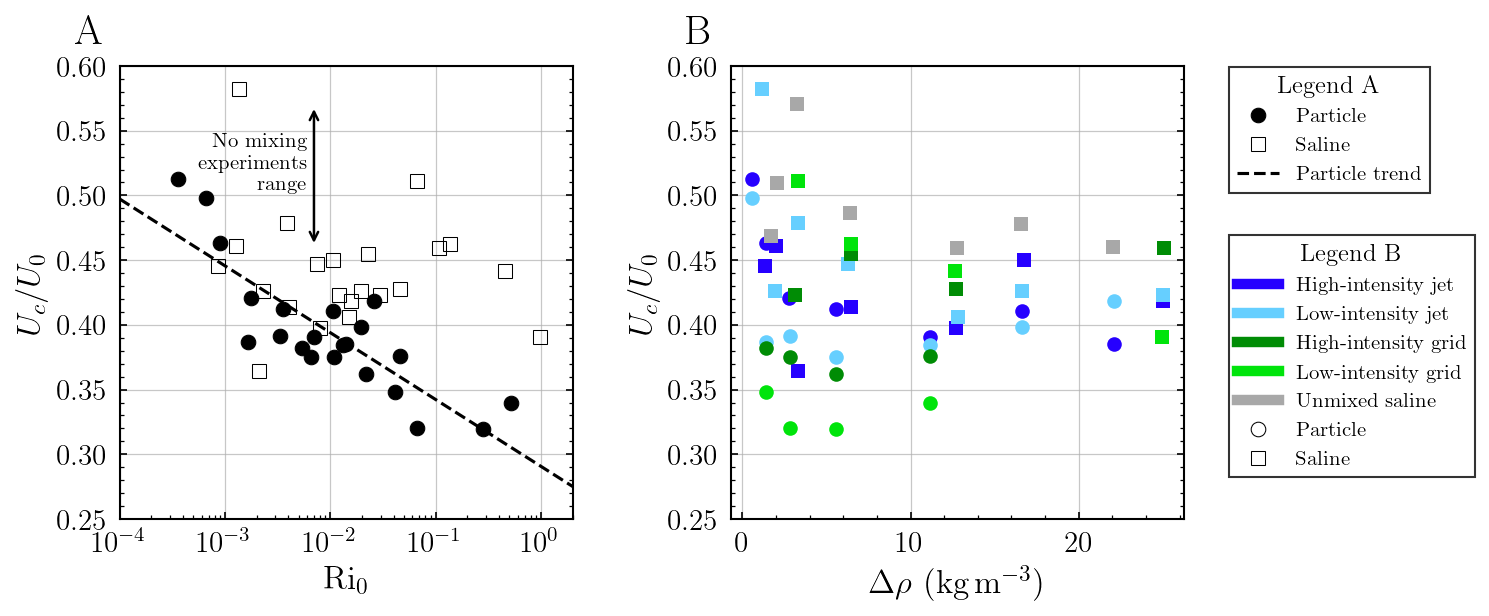

In [32]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4.5))

# plot all my data colored by mixing type and marker by saline/part
for mixing_type, color in mixing_c_map.items():
    for t, marker in type_marker_map.items():
        df_sub = metadata[(metadata["mixing"] == mixing_type) & (metadata["type"] == t)]
        if df_sub.empty:
            continue

        ax[1].plot(
            df_sub["del_rho"],
            df_sub["u_c"] / df_sub["u_0"],
            color=color,
            marker=marker,
            linestyle="",
            markersize=7,
        )

for t, marker in type_marker_map.items():
    df_sub = metadata[metadata["type"] == t]
    c = "none" if t == "saline" else "black"

    ax[0].semilogx(
        df_sub["Ri_0"],
        df_sub["u_c"] / df_sub["u_0"],
        color=c,
        marker=marker,
        markerfacecolor=c,
        markeredgecolor="k",
        markeredgewidth=0.5,
        markersize=7,
        linestyle="",
    )
    if t == "saline":
        nm = df_sub[df_sub.mixing == "none"]
    if t == "part":
        x = np.log10(df_sub["Ri_0"].values)
        m, b = np.polyfit(x, df_sub["u_c"].values / df_sub["u_0"].values, 1)
        x_fit = np.linspace(-4, 1, 200)
        ax[0].plot(10**x_fit, m * x_fit + b, "k--")

ylim = [0.25, 0.6]

ax[1].set(
    # xlim=[0,5],
    ylim=ylim,
    xlabel="$\\Delta \\rho$ (kg$\\,$m$^{-3}$)",
    ylabel="$U_c/U_0$",
)

ax[0].set(xlim=[0.0001, 2], ylim=ylim, xlabel="Ri$_0$", ylabel="$U_c/U_0$")


ax[0].annotate(
    "",
    xy=(0.7e-2, 0.57),
    xytext=(0.7e-2, 0.46),
    arrowprops=dict(arrowstyle="<->", color="k", lw=1.2),
)
ax[0].text(
    6e-3, 0.525, "No mixing\nexperiments\nrange", fontsize=10, va="center", ha="right"
)

ri_legend = []

ri_legend.extend(
    [
        Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            label="Particle",
            markerfacecolor="black",
            markeredgecolor="k",
            markeredgewidth=0.5,
            markersize=7,
        ),
        Line2D(
            [0],
            [0],
            marker="s",
            color="w",
            label="Saline",
            markerfacecolor="white",
            markeredgecolor="k",
            markeredgewidth=0.5,
            markersize=7,
        ),
        Line2D([0], [0], color="k", linestyle="--", label="Particle trend"),
    ]
)

# ============== Labels ==============
for axis, label in zip(ax, ["A", "B"]):
    axis.set_box_aspect(1)
    axis.annotate(
        label,
        xy=(-0.1, 1.05),
        xycoords="axes fraction",
        fontsize=20,
        fontweight="bold",
    )

# Leave space on RHS for legends
fig.subplots_adjust(wspace=0.35, right=0.72)

# --- Legend 1: Literature comparison ---
leg1 = fig.legend(
    handles=ri_legend,
    loc="upper left",
    bbox_to_anchor=(1.01, 0.85),
    fontsize=10,
    title="Legend A",
    frameon=True,
)

# --- Legend 2: Present study ---
leg2 = fig.legend(
    handles=my_legend_elements,
    loc="upper left",
    bbox_to_anchor=(1.01, 0.6),
    fontsize=10,
    title="Legend B",
    frameon=True,
    ncols=1,
)


for axis in ax:
    axis.set_box_aspect(1)

plt.tight_layout()
fig.subplots_adjust(wspace=0.35)
plt.savefig("../figures/figure_11.png", bbox_inches="tight", dpi=300)
plt.show()